# Crop Water Requirement Prediction

**Data Science Internship Project**



## 1. Import Libraries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Generate / Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\WIN 11\Downloads\water_quality_.csv")
df

,ph,Hardness,Solids,Chloramines,Sulfate,Organic_carbon,Trihalomethanes,Turbidity,Check
0,NaN,204.890456,20791.31898,7.300212,368.516441,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.05786,6.635246,NaN,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.54173,9.275884,NaN,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,18.436525,100.341674,4.628771,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681736,47580.99160,7.166639,359.948574,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.80216,8.061362,NaN,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.57822,7.350233,NaN,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.86938,6.303357,NaN,11.168946,77.488213,4.708658,1


In [3]:
n = 1500

crops = ['Wheat', 'Rice', 'Maize', 'Sugarcane', 'Cotton', 'Soybean']
soils = ['Sandy', 'Clay', 'Loamy', 'Silty']

# Approximate crop water coefficients (Kc) and soil water-holding factors
crop_base_kc = {'Wheat': 0.90, 'Rice': 1.20, 'Maize': 1.00,
                 'Sugarcane': 1.15, 'Cotton': 0.95, 'Soybean': 0.85}
soil_factor = {'Sandy': 1.15, 'Clay': 0.85, 'Loamy': 1.00, 'Silty': 0.95}

df = pd.DataFrame({
    'Crop_Type': np.random.choice(crops, n),
    'Soil_Type': np.random.choice(soils, n),
    'Temperature_C': np.round(np.random.normal(28, 6, n), 1),
    'Humidity_%': np.round(np.random.uniform(30, 90, n), 1),
    'Wind_Speed_kmph': np.round(np.random.uniform(2, 20, n), 1),
    'Solar_Radiation_MJm2': np.round(np.random.uniform(10, 28, n), 1),
    'Rainfall_mm': np.round(np.abs(np.random.normal(5, 8, n)), 1),
    'Soil_Moisture_%': np.round(np.random.uniform(10, 60, n), 1),
    'Growth_Stage_Days': np.random.randint(10, 150, n),
})

def estimate_eto(row):
    """Simplified reference evapotranspiration estimate."""
    val = (0.0023 * (row['Temperature_C'] + 17.8) * np.sqrt(max(row['Wind_Speed_kmph'], 0.1))
           * row['Solar_Radiation_MJm2'] * 0.05
           - 0.01 * row['Humidity_%'] + 0.1 * row['Wind_Speed_kmph'])
    return max(0, val)

df['ETo_estimate'] = df.apply(estimate_eto, axis=1)
df['Kc'] = df['Crop_Type'].map(crop_base_kc)
df['SoilFactor'] = df['Soil_Type'].map(soil_factor)

df['Water_Requirement_mm'] = (
    df['ETo_estimate'] * df['Kc'] * df['SoilFactor']
    - 0.15 * df['Rainfall_mm']
    - 0.05 * df['Soil_Moisture_%']
    + 0.02 * df['Growth_Stage_Days']
    + np.random.normal(0, 0.5, n)
)
df['Water_Requirement_mm'] = df['Water_Requirement_mm'].clip(lower=0.5).round(2)
df.drop(columns=['ETo_estimate', 'Kc', 'SoilFactor'], inplace=True)

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (1500, 10)


,Crop_Type,Soil_Type,Temperature_C,Humidity_%,Wind_Speed_kmph,Solar_Radiation_MJm2,Rainfall_mm,Soil_Moisture_%,Growth_Stage_Days,Water_Requirement_mm
0,Sugarcane,Clay,26.6,77.1,8.2,14.1,9.1,47.5,54,0.50
1,Cotton,Clay,21.7,65.4,2.6,20.8,7.2,56.8,25,0.50
2,Maize,Silty,30.3,30.4,15.4,22.6,5.5,39.6,40,0.50
3,Cotton,Loamy,36.2,76.4,16.4,11.6,0.8,10.6,59,2.15
4,Cotton,Sandy,22.0,72.1,4.9,19.0,0.1,11.7,131,2.67


## 3. Exploratory Data Analysis (EDA)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Crop_Type             1500 non-null   str    
 1   Soil_Type             1500 non-null   str    
 2   Temperature_C         1500 non-null   float64
 3   Humidity_%            1500 non-null   float64
 4   Wind_Speed_kmph       1500 non-null   float64
 5   Solar_Radiation_MJm2  1500 non-null   float64
 6   Rainfall_mm           1500 non-null   float64
 7   Soil_Moisture_%       1500 non-null   float64
 8   Growth_Stage_Days     1500 non-null   int32  
 9   Water_Requirement_mm  1500 non-null   float64
dtypes: float64(7), int32(1), str(2)
memory usage: 111.5 KB


In [5]:
df.describe()


,Temperature_C,Humidity_%,Wind_Speed_kmph,Solar_Radiation_MJm2,Rainfall_mm,Soil_Moisture_%,Growth_Stage_Days,Water_Requirement_mm
count,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,28.23460,59.328000,10.903200,19.142267,7.600267,34.733600,78.410000,0.751840
std,5.92835,17.220273,5.245397,5.176747,5.573933,14.362364,41.142205,0.553635
min,7.70000,30.000000,2.000000,10.100000,0.000000,10.100000,10.000000,0.500000
25%,24.30000,44.475000,6.375000,14.875000,3.200000,22.800000,41.000000,0.500000
50%,28.40000,59.100000,11.000000,19.200000,6.600000,34.450000,78.000000,0.500000
75%,32.32500,74.400000,15.200000,23.700000,10.825000,46.825000,115.000000,0.660000
max,49.00000,89.900000,20.000000,28.000000,32.300000,60.000000,149.000000,3.870000


In [6]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Crop_Type               0
Soil_Type               0
Temperature_C           0
Humidity_%              0
Wind_Speed_kmph         0
Solar_Radiation_MJm2    0
Rainfall_mm             0
Soil_Moisture_%         0
Growth_Stage_Days       0
Water_Requirement_mm    0
dtype: int64


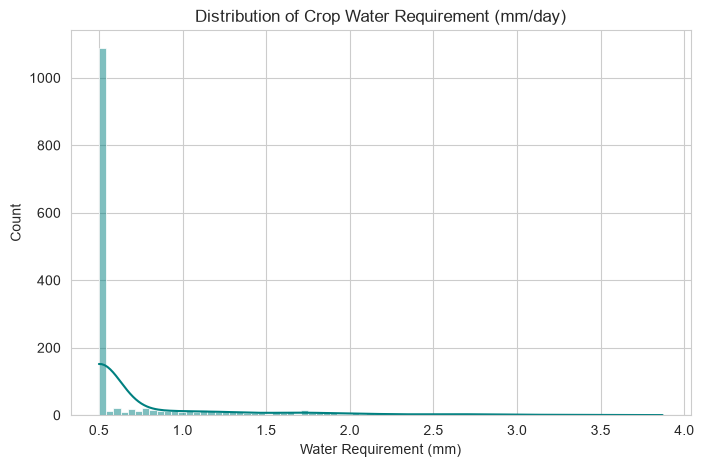

In [7]:
# Distribution of target variable
plt.figure(figsize=(8, 5))
sns.histplot(df['Water_Requirement_mm'], kde=True, color='teal')
plt.title('Distribution of Crop Water Requirement (mm/day)')
plt.xlabel('Water Requirement (mm)')
plt.show()


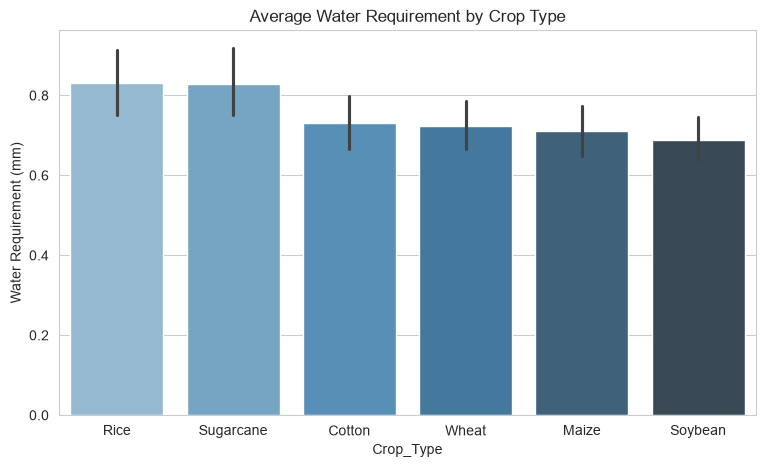

In [8]:
# Average water requirement by crop type
plt.figure(figsize=(9, 5))
order = df.groupby('Crop_Type')['Water_Requirement_mm'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='Crop_Type', y='Water_Requirement_mm', order=order, palette='Blues_d')
plt.title('Average Water Requirement by Crop Type')
plt.ylabel('Water Requirement (mm)')
plt.show()


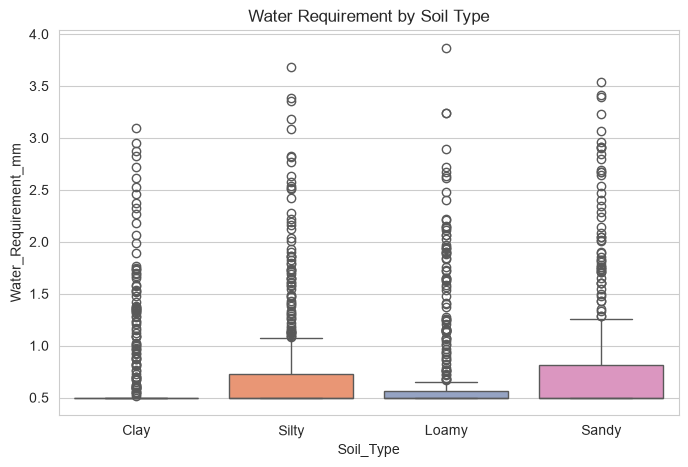

In [9]:
# Water requirement by soil type
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Soil_Type', y='Water_Requirement_mm', palette='Set2')
plt.title('Water Requirement by Soil Type')
plt.show()


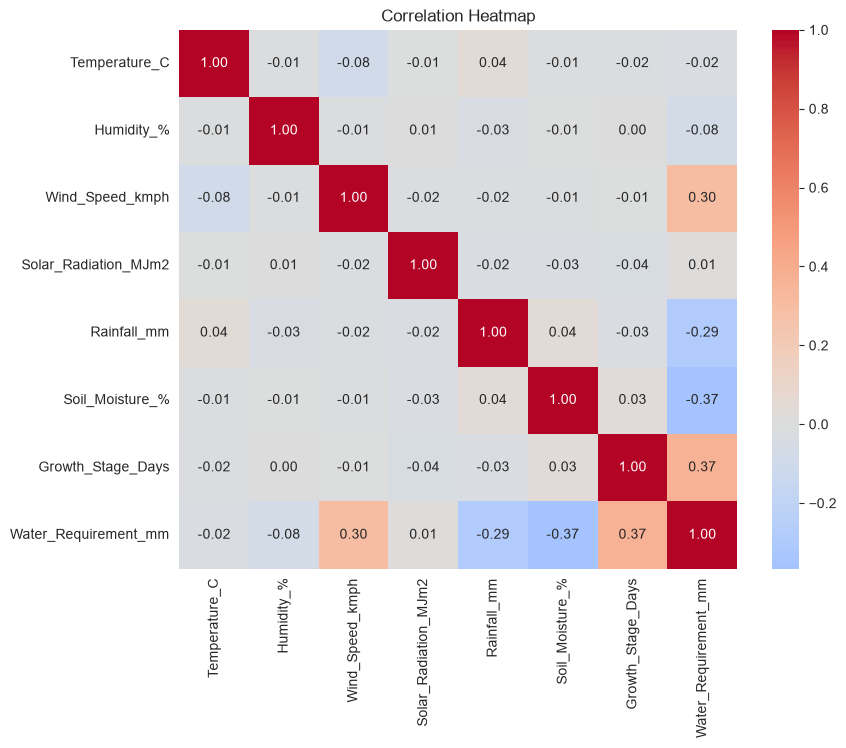

In [10]:
# Correlation heatmap for numeric features
plt.figure(figsize=(9, 7))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


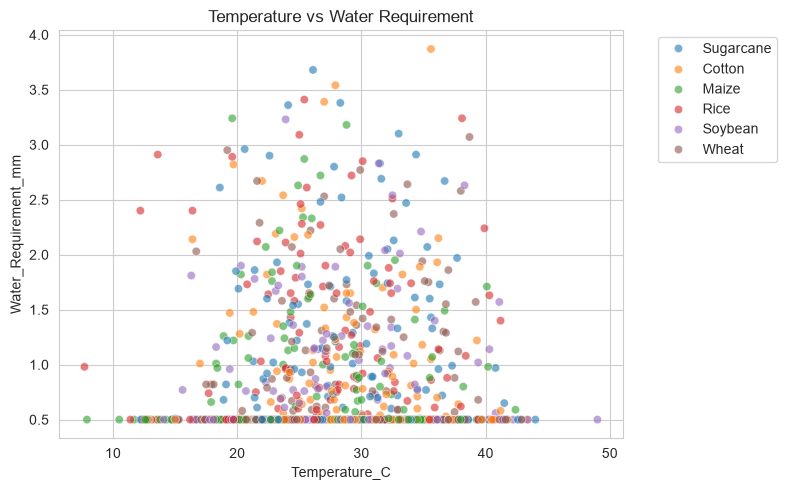

In [11]:
# Relationship between temperature and water requirement
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Temperature_C', y='Water_Requirement_mm', hue='Crop_Type', alpha=0.6)
plt.title('Temperature vs Water Requirement')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 4. Data Preprocessing

In [12]:
# Encode categorical variables
le_crop = LabelEncoder()
le_soil = LabelEncoder()

df['Crop_Type_enc'] = le_crop.fit_transform(df['Crop_Type'])
df['Soil_Type_enc'] = le_soil.fit_transform(df['Soil_Type'])

feature_cols = ['Crop_Type_enc', 'Soil_Type_enc', 'Temperature_C', 'Humidity_%',
                 'Wind_Speed_kmph', 'Solar_Radiation_MJm2', 'Rainfall_mm',
                 'Soil_Moisture_%', 'Growth_Stage_Days']
target_col = 'Water_Requirement_mm'

X = df[feature_cols]
y = df[target_col]

print("Feature columns:", feature_cols)
print("Target column:", target_col)


Feature columns: ['Crop_Type_enc', 'Soil_Type_enc', 'Temperature_C', 'Humidity_%', 'Wind_Speed_kmph', 'Solar_Radiation_MJm2', 'Rainfall_mm', 'Soil_Moisture_%', 'Growth_Stage_Days']
Target column: Water_Requirement_mm


In [13]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Feature scaling (helps Linear Regression; tree models are scale-invariant but it's harmless)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 1200
Test set size: 300


## 5. Model Building

In [14]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=RANDOM_STATE)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
        'predictions': y_pred
    }

results_df = pd.DataFrame({k: {m: v[m] for m in ['MAE', 'RMSE', 'R2']} for k, v in results.items()}).T
results_df.sort_values('R2', ascending=False)


,MAE,RMSE,R2
Random Forest,0.149570,0.264285,0.760810
Gradient Boosting,0.182499,0.281116,0.729374
Linear Regression,0.303256,0.410477,0.423000


## 6. Model Evaluation & Comparison

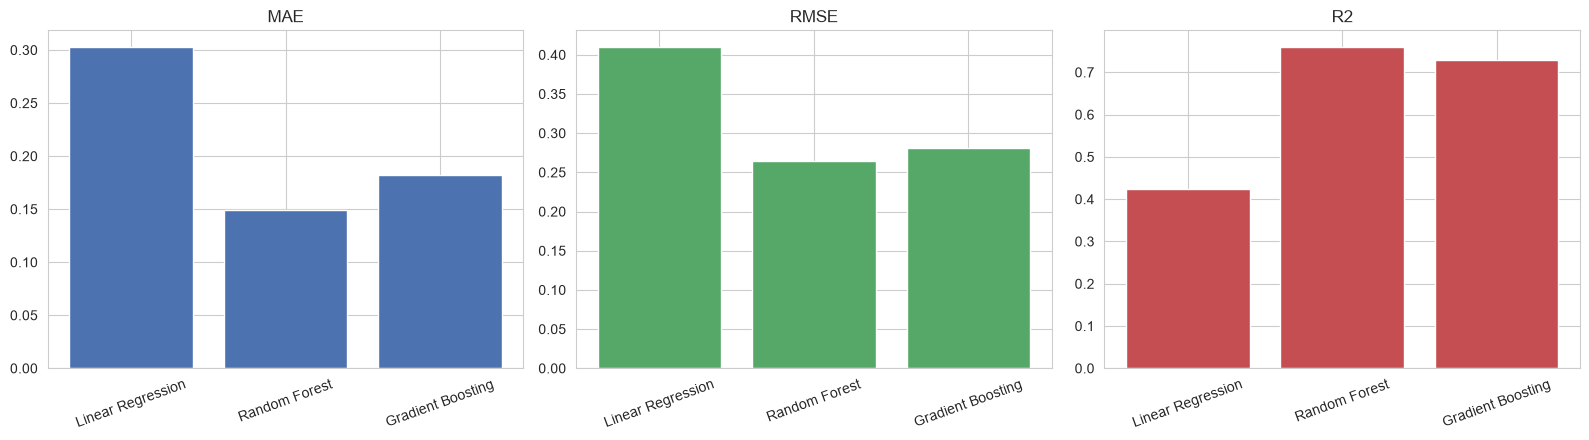

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metrics = ['MAE', 'RMSE', 'R2']
colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, metric, color in zip(axes, metrics, colors):
    values = [results[m][metric] for m in results]
    ax.bar(list(results.keys()), values, color=color)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


In [16]:
# Best model based on R2 score
best_model_name = max(results, key=lambda m: results[m]['R2'])
best_model = models[best_model_name]
print(f"Best performing model: {best_model_name} (R2 = {results[best_model_name]['R2']:.3f})")


Best performing model: Random Forest (R2 = 0.761)


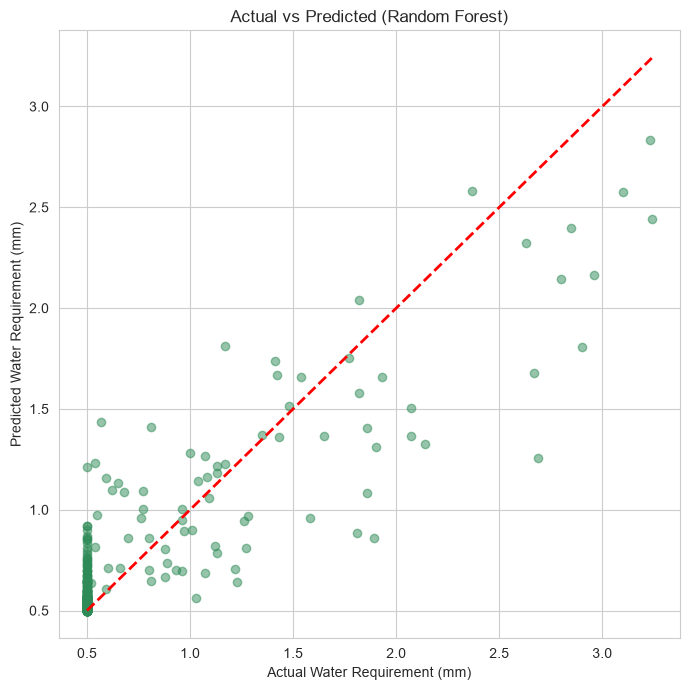

In [17]:
# Actual vs Predicted plot for the best model
y_pred_best = results[best_model_name]['predictions']

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='seagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Water Requirement (mm)')
plt.ylabel('Predicted Water Requirement (mm)')
plt.title(f'Actual vs Predicted ({best_model_name})')
plt.tight_layout()
plt.show()


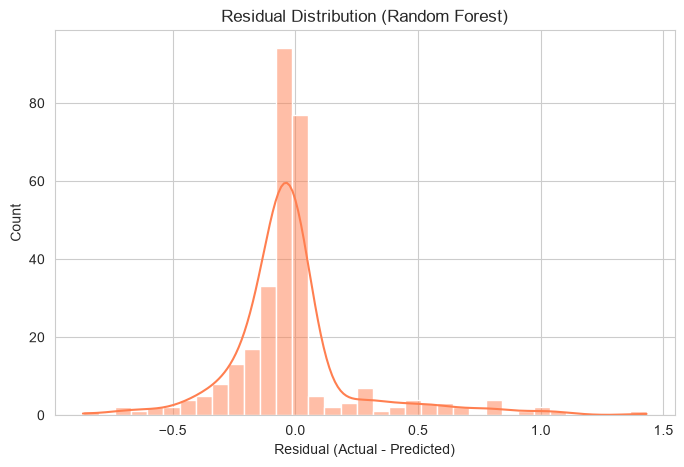

In [18]:
# Residual plot
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='coral')
plt.title(f'Residual Distribution ({best_model_name})')
plt.xlabel('Residual (Actual - Predicted)')
plt.show()


## 7. Feature Importance

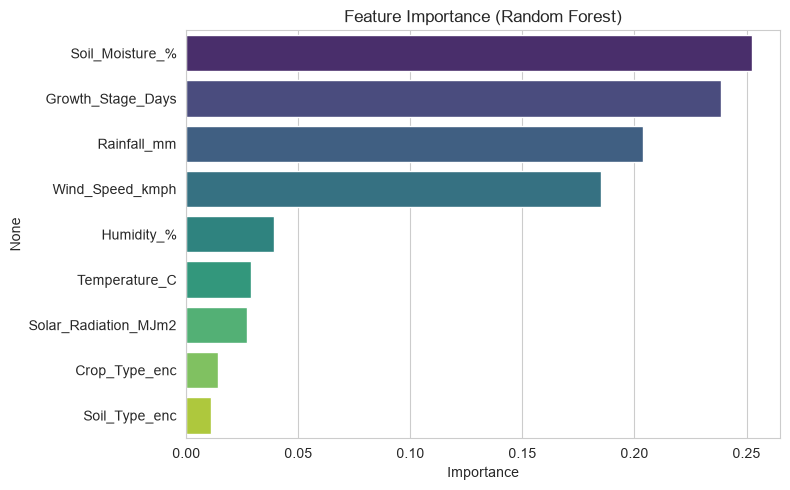

Soil_Moisture_%         0.252330
Growth_Stage_Days       0.238580
Rainfall_mm             0.203662
Wind_Speed_kmph         0.185191
Humidity_%              0.039028
Temperature_C           0.028684
Solar_Radiation_MJm2    0.027055
Crop_Type_enc           0.014238
Soil_Type_enc           0.011232
dtype: float64


In [19]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.values, y=importances.index, palette='viridis')
    plt.title(f'Feature Importance ({best_model_name})')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print(importances)
else:
    coeffs = pd.Series(best_model.coef_, index=feature_cols).sort_values(key=abs, ascending=False)
    print(coeffs)


## 8. Predicting on New Data

Example: predict the water requirement for a new set of field conditions.

In [20]:
def predict_water_requirement(crop_type, soil_type, temperature, humidity,
                               wind_speed, solar_radiation, rainfall,
                               soil_moisture, growth_stage_days):
    """Predict crop water requirement (mm) for a single new observation."""
    crop_enc = le_crop.transform([crop_type])[0]
    soil_enc = le_soil.transform([soil_type])[0]

    new_data = pd.DataFrame([{
        'Crop_Type_enc': crop_enc,
        'Soil_Type_enc': soil_enc,
        'Temperature_C': temperature,
        'Humidity_%': humidity,
        'Wind_Speed_kmph': wind_speed,
        'Solar_Radiation_MJm2': solar_radiation,
        'Rainfall_mm': rainfall,
        'Soil_Moisture_%': soil_moisture,
        'Growth_Stage_Days': growth_stage_days
    }])[feature_cols]

    new_data_scaled = scaler.transform(new_data)
    prediction = best_model.predict(new_data_scaled)[0]
    return round(prediction, 2)

# Example usage
example_prediction = predict_water_requirement(
    crop_type='Rice', soil_type='Clay', temperature=32, humidity=55,
    wind_speed=8, solar_radiation=22, rainfall=2, soil_moisture=25,
    growth_stage_days=60
)

print(f"Predicted water requirement: {example_prediction} mm/day")


Predicted water requirement: 0.54 mm/day


## 9. Save the Trained Model

Save the model, scaler, and encoders so they can be reused later (e.g., in a web app or API) without retraining.

In [21]:
import joblib
import os

# Folder where the pickle files will be saved
save_dir = r"C:\Users\WIN 11\Desktop\dipanshu"
os.makedirs(save_dir, exist_ok=True)

joblib.dump(best_model, os.path.join(save_dir, "crop_water_model.pkl"))
joblib.dump(scaler, os.path.join(save_dir, "scaler.pkl"))
joblib.dump(le_crop, os.path.join(save_dir, "crop_encoder.pkl"))
joblib.dump(le_soil, os.path.join(save_dir, "soil_encoder.pkl"))

print(f"Model and preprocessing objects saved successfully to {save_dir}")


Model and preprocessing objects saved successfully!
